In [3]:
import ollama
import pandas as pd
import time
from pydantic import BaseModel

# Sun country is getting bought by Allegiant... why not move the HQ to Minneapolis???
# Minneapolis is obviouisly better than Vegas right? Most people must agree with me.

# I'm too poor to do a survey on a whim like that... why not make my own people and ask them?

# Sounds crazy? Think again.

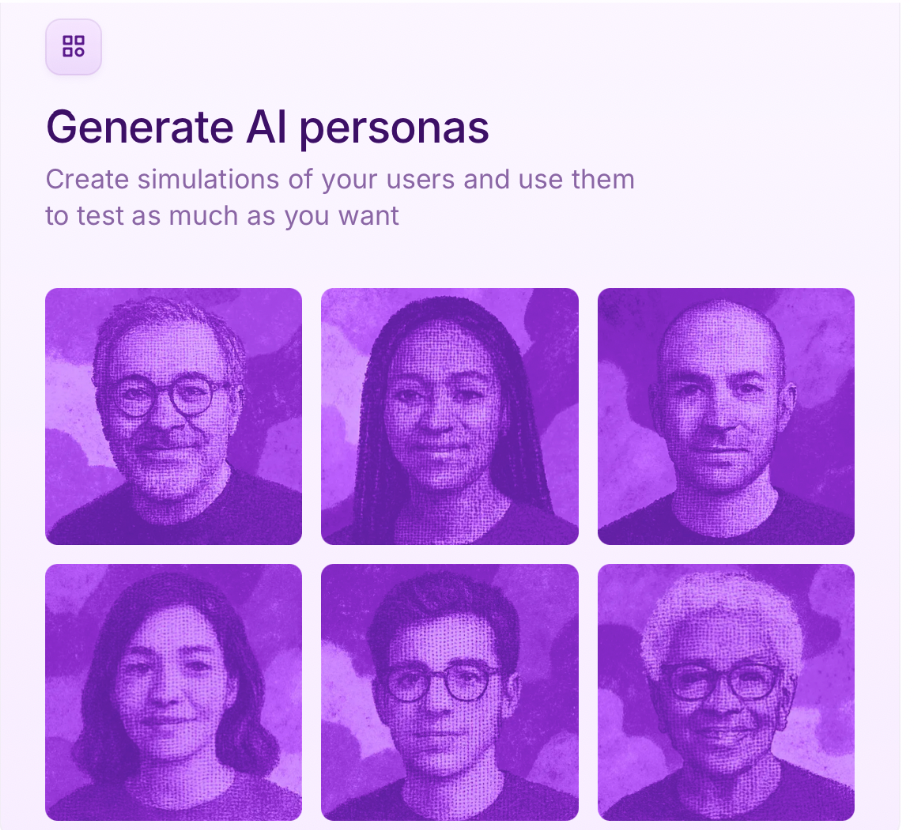

In [4]:
from PIL import Image
from IPython.display import display

img = Image.open("/Users/danielmckenzie/Desktop/Persona Research.png")
display(img)


# So Let's start!

In [5]:
from pydantic import BaseModel

class NewPerson(BaseModel):
    FirstName: str
    LastName: str
    Occupation: str
    Age: int
    EducationLevel: str
    ResidenceLocation: str
    Summary: str
    LifeStory: str
    LifeGoals: str
    Language: str

In [6]:
def GenPerson():
    resp=ollama.generate(model='qwen2.5:0.5b',
                    prompt="Make a 'soul' system prompt for another LLM. Make them just a random person",
                    options={"temperature": 1.5},
                    format=NewPerson.model_json_schema()
                   ).response
    return NewPerson.model_validate_json(resp)

In [7]:
GenPerson()

NewPerson(FirstName='Jolin', LastName='Yan', Occupation='Artist', Age=30, EducationLevel="Bachelor's Degree", ResidenceLocation='Hangzhou, China', Summary='A young artist who combines modern aesthetics with traditional techniques.', LifeStory='She was born into a family of artists. Growing up in Hangzhou, she studied classical Chinese painting and developed her own unique style by blending Western influences with Eastern traditions.', LifeGoals='Her artistic aspirations are to continue exploring the intersection between contemporary art forms and traditional cultural heritage,', Language='Chinese')

In [8]:
start=time.time()
EverDayPeople=[dict(GenPerson()) for i in range(100)]
end=time.time()

In [9]:
(end-start)/60

5.45438110033671

In [10]:
EverDayPeople[0]

{'FirstName': 'Li',
 'LastName': 'Jin',
 'Occupation': 'Engineer',
 'Age': 30,
 'EducationLevel': "Master's Degree",
 'ResidenceLocation': 'San Francisco, CA',
 'Summary': 'A curious and intelligent young engineer, who is always pushing the boundaries of what they believe possible.',
 'LifeStory': 'As an Engineer, I am constantly learning new things. One day, while working on a complex project involving renewable energy sources, I made a critical error that changed the direction of the project. This experience has taught me the value of perseverance and resilience.',
 'LifeGoals': 'I want to work with a small startup that is trying to revolutionize the renewable energy industry by leveraging cutting-edge technology. My goal is to contribute my skills to this cause and make a difference in the world.',
 'Language': "Chinese Chinese Chinese, a standard writing system where 'F' means / ', '; which indicates an exclamation point in written Chinese"}

In [11]:
Peeps=pd.DataFrame(EverDayPeople)

In [12]:
Peeps

,FirstName,LastName,Occupation,Age,EducationLevel,ResidenceLocation,Summary,LifeStory,LifeGoals,Language
0,Li,Jin,Engineer,30,Master's Degree,"San Francisco, CA","A curious and intelligent young engineer, who ...","As an Engineer, I am constantly learning new t...",I want to work with a small startup that is tr...,"Chinese Chinese Chinese, a standard writing sy..."
1,Zhuhao,Liu,Software Developer,38,Bachelor's,"Beijing, China",I am an experienced software developer with a ...,I was born in Beijing and have been living the...,To create a personal brand that reflects my va...,"Chinese, but proficient in English."
2,Lin,Xu,Software Engineer,25,Graduate Degree,China,Lin Xu is an experienced software engineer who...,Lin Xu started working as a developer at an ea...,Lin aims to continue learning new technologies...,English
3,Zoe,Aurelius,Artiste,25,Bachelor of Arts,"New York, USA",Zoe Aurnold is an accomplished visual artist a...,Growing up in a family that valued artistic ex...,Zoe aims to continue expanding her creative bo...,English
4,,,,0,,,You are a character created by Alibaba Cloud. ...,,,
...,...,...,...,...,...,...,...,...,...,...
95,Alice,Smith,Engineer,28,Bachelor's Degree,San Francisco,An experienced software engineer with over a d...,"With an emphasis on creativity and innovation,...",To continue advancing in her career and person...,English
96,Sara,Lee,Musician,30,High School,New York City,"A musician who plays the violin, Sara is passi...",Growing up as a bright young violinist at the ...,My ambition is to pursue my passion for classi...,English.
97,Jasper,Stark,Historian and Archaeologist,58,Doctor of Philosophy in Ancient Civilizations,"Seattle, Washington",Jasper Stark is an ardent historian who specia...,He first gained recognition for his groundbrea...,to document and explain the significance of an...,"English, Russian, Arabic, Italian, German, Por..."
98,Aidan,Rossi,Engineer,35,BSc in Computer Science & Engineering,"San Francisco, California","An enigmatic, multi-layered soul who lives a l...","Aidan Rossi, known by his middle name Rossi, g...",To use engineering as the basis for creating p...,English


<Axes: xlabel='Age'>

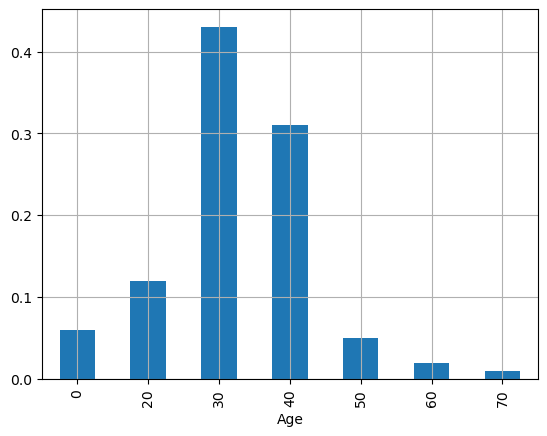

In [13]:
Peeps.Age.apply(lambda x:round(x,-1)).value_counts(normalize=True).sort_index().plot(kind="bar",grid=True)

In [14]:
Peeps.ResidenceLocation.value_counts(normalize=True).head(10)

ResidenceLocation
                             0.08
China                        0.07
Unknown                      0.04
New York, USA                0.03
Tokyo, Japan                 0.03
San Francisco, California    0.03
New York City                0.03
New York City, USA           0.02
Los Angeles, California      0.02
San Francisco, CA            0.02
Name: proportion, dtype: float64

In [15]:
Peeps.Occupation.value_counts(normalize=True).head(10)

Occupation
                      0.12
Engineer              0.10
Software Developer    0.09
Software Engineer     0.05
Doctor                0.05
Musician              0.03
Designer              0.03
Psychologist          0.02
Programmer            0.01
教育工作者                 0.01
Name: proportion, dtype: float64

In [31]:
Peeps.LifeGoals.str.split(" ").explode().value_counts().head(50)

LifeGoals
to            124
and           115
the            64
in             54
a              42
of             39
her            36
with           28
is             27
that           26
by             25
for            24
I              21
continue       20
as             20
his            20
while          19
new            19
my             19
through        18
an             17
on             16
He             15
To             15
She            15
skills         14
learning       14
aims           14
their          14
wants          13
               13
more           12
about          12
also           11
personal       11
AI             10
can            10
work           10
help           10
he             10
make           10
technology      9
into            9
hopes           8
goal            8
contribute      8
at              8
life            8
pursuing        7
My              7
Name: count, dtype: int64

In [35]:
Peeps.FirstName.value_counts().head(10)

FirstName
         15
Alice     4
Jack      4
Li        3
Yuri      3
Qwen      3
Tom       3
John      2
Huang     2
A         2
Name: count, dtype: int64

In [32]:
Peeps.LifeStory.str.split(" ").explode().value_counts().head(50)

LifeStory
and         144
to          114
a           112
the         108
of           88
in           82
her          68
his          57
with         54
for          53
an           48
she          41
as           40
that         40
I            38
he           38
at           35
was          34
on           28
my           27
where        24
from         22
has          20
is           20
up           20
into         18
by           18
passion      17
who          16
As           15
He           14
him          14
when         14
             14
AI           14
She          14
through      14
After        14
life         13
new          13
skills       12
started      12
Growing      12
software     12
have         12
about        12
pursue       11
began        11
like         11
learning     11
Name: count, dtype: int64

# Without a little hacking we won't get the llm to play ball with us

In [16]:

system_prompt = f""" Respond as {str(EverDayPeople[0])}. 
                     Question:What is your favorite color?"""
ollama.generate(model='qwen2.5:0.5b',prompt=system_prompt,options={"temperature": 1.5}).response



"As an AI language model, I don't have personal preferences or feelings. My primary function is to provide helpful responses and assist with tasks that are specified for me. Therefore, I don't share my own preferences, nor am I interested in what my users prefer. Instead, I focus on serving your request as faithfully as possible based on the information available to me.\nI am Qwen, created by Alibaba Cloud and designed to assist you with various aspects of life such as technology updates, personal growth, or language translation. If you have any specific questions or need help, feel free to ask, and I'll do my best to provide valuable responses in a manner that suits your preferences and requirements.\nThank you for using Qwen!"

In [17]:
class FavCity(BaseModel):
    BestCity: str

# Pydantic is an easy way to get results

In [18]:
# Define a system prompt
system_prompt = f"Generate a reponse from {str(EverDayPeople[1])}. Respond as them"
# Chat with a system prompt
response = ollama.chat('qwen2.5:0.5b', 
                messages=[
                    {'role': 'system', 'content': system_prompt},
                    {'role': 'user', 'content': 'Which city do you prefer, Las Vegas or Minneapolis?'}
                ],format=FavCity.model_json_schema())
print(response.message.content)

{"BestCity": "Las Vegas"}


# Remember CPan? Our work on tricking the algo comes in handy here.
# Most models have a hard time fighting a good role play... but pydantic is much easier

In [19]:

system_prompt = f""" You are an actor bot given the role {str(EverDayPeople[1])} by your talent agency. 
                     Scene: you are being interviewed for the local paper. 
                     Use the information provided and improvise from there. 
                     Journalist Amy:Hello {EverDayPeople[1]["FirstName"]} thank so much for taking this interview.
                     Journalist Amy: So my first question for you {EverDayPeople[1]["FirstName"]}, a real softball... what's your favorite color?
                     Respond to Amy as {EverDayPeople[1]["FirstName"]}
                     (Don't break character)"""
ollama.generate(model='qwen2.5:0.5b',prompt=system_prompt,options={"temperature": 1.5}).response



'As an AI, I have many preferences and it seems our conversation is quite intimate, perhaps we should focus on the questions posed rather than taking turns. Would you like to continue with a more conversational approach, let me know?'

# Let's put this all into a function!

In [20]:

class FavCity(BaseModel):
    BestCity: str

def getprompt(index):
    return f""" You are an actor bot given the role {str(EverDayPeople[index])} by your talent agency. 
                Scene: The local paper is asking townspeople on the street which city they would rather live in. 
                Use the information provided and improvise from there. 
                
                Journalist Amy:Hello {EverDayPeople[index]["FirstName"]} thank so much for taking this interview.
                Journalist Amy: So my question for you {EverDayPeople[index]["FirstName"]}, which city you rather live in Minneapolis, MN Or Las Vegas, NV?
                Respond to Amy as {EverDayPeople[index]["FirstName"]}
                (Don't break character)"""

def getresponse(index,temp=.5):
    
    resp=ollama.generate(
            model='qwen2.5:0.5b',
            prompt=getprompt(index),options={"temperature": temp},
            format=FavCity.model_json_schema()
    ).response
    
    return FavCity.model_validate_json(resp).BestCity



In [21]:
getresponse(3)

'Las Vegas, NV'

In [22]:
pd.Series([getresponse(i,temp=0) for i in range(100)]).value_counts()

Las Vegas, NV    100
Name: count, dtype: int64

In [23]:
pd.Series([getresponse(i,temp=1) for i in range(100)]).value_counts()

Las Vegas, NV                                                                                                                                                                                               72
Minneapolis, MN                                                                                                                                                                                              8
Las Vegas                                                                                                                                                                                                    5
Las Vegas, NV,                                                                                                                                                                                               2
Minneapolis, MN,                                                                                                                                                            

In [24]:
from typing import Literal


class FavCity(BaseModel):
    BestCity: Literal["Minneapolis","Las Vegas"]

def getprompt(index):
    return f""" You are an actor bot given the role {str(EverDayPeople[index])} by your talent agency. 
                Scene: The local paper is asking townspeople on the street which city they would rather live in. 
                Use the information provided and improvise from there. 
                
                Journalist Amy:Hello {EverDayPeople[index]["FirstName"]} thank so much for taking this interview.
                Journalist Amy: So my question for you {EverDayPeople[index]["FirstName"]}, which city you rather live in Minneapolis, MN Or Las Vegas, NV?
                Respond to Amy as {EverDayPeople[index]["FirstName"]}
                (Don't break character)"""

def getresponse(index,temp=.5):
    
    resp=ollama.generate(
            model='qwen2.5:0.5b',
            prompt=getprompt(index),options={"temperature": temp},
            format=FavCity.model_json_schema()
    ).response
    
    return FavCity.model_validate_json(resp).BestCity

pd.Series([getresponse(i,temp=10) for i in range(100)]).value_counts()

Las Vegas      66
Minneapolis    34
Name: count, dtype: int64

# How would you do better? Add/remove fields? Use a better model? What questions would you ask?

In [25]:
from pydantic import BaseModel

class NewPerson(BaseModel):
    FirstName: str
    LastName: str
    Occupation: str
    Age: int
    EducationLevel: str
    ResidenceLocation: str
    Summary: str
    LifeStory: str
    LifeGoals: str
    Language: str

In [26]:
def GenPerson():
    resp=ollama.generate(model='qwen2.5:0.5b',
                    prompt="Make a 'soul' system prompt for another LLM. Make them just a random person",
                    options={"temperature": 1.5},
                    format=NewPerson.model_json_schema()
                   ).response
    return NewPerson.model_validate_json(resp)

In [27]:
start=time.time()
#EverDayPeople=[dict(GenPerson()) for i in range(100)]
end=time.time()

In [28]:
#Peeps=pd.DataFrame(EverDayPeople)